In [3]:
# load lib
import warnings
warnings.filterwarnings('ignore')
from datetime import datetime, timedelta
import numpy as np
import vectorbt as vbt
import pandas as pd
import numba as nb
import optuna # Import Optuna

# Add backend directory to path for importing app modules
import os, sys, pathlib
from pathlib import Path
ROOT = pathlib.Path('..').resolve()
sys.path.insert(0, str(ROOT))

In [4]:
from backend.app.services.data_loader import load_stocks

BENCHMARK = 'VNINDEX'

df = load_stocks(refresh=False)

print(f'Shape : {df.shape}  |  {df.index[0].date()} → {df.index[-1].date()}')
df

Loading from HDF5 cache: stocks_data_latest.h5
Shape: (2499, 985)  |  2016-07-11 → 2026-07-08
Shape : (2499, 985)  |  2016-07-11 → 2026-07-08


close                                                          \
symbol        AAA    ABB        ACB    ACV   ADS    AGG    AGR        ANV   
date                                                                        
2016-07-11  14.76   7.48   2.553842  20.63  3.27  15.28   2.42   1.144459   
2016-07-12  15.67   7.48   2.553842  20.63  3.49  15.28   2.33   1.094700   
2016-07-13  15.72   7.48   2.622864  20.63  3.70  15.28   2.42   1.144459   
2016-07-14  15.22   7.48   2.622864  20.63  3.73  15.28   2.33   1.161046   
2016-07-15  15.22   7.48   2.622864  20.63  3.78  15.28   2.42   1.144459   
...           ...    ...        ...    ...   ...    ...    ...        ...   
2026-07-02   7.36  18.60  22.650000  43.70  8.56  11.70  15.40  21.500000   
2026-07-03   7.40  18.70  22.650000  43.60  8.39  11.70  16.00  20.950000   
2026-07-06   7.31  18.60  22.200000  43.20  8.12  11.65  15.20  20.400000   
2026-07-07   7.50  18.70  22.600000  42.80  7.98  11.65  16.00  20.250000   
2026-07-08   7.47  19.00  22.700000  43.00  7.98  11.60  15.80  19.750000   

                         ...       volume                                   \
symbol        APH   ASM  ...      VNINDEX        VNM       VOS         VPB   
date                     ...                                                 
2016-07-11  30.17  6.51  ...  146647984.0   554950.0   68000.0  58299312.0   
2016-07-12  30.17  6.51  ...  149112960.0   644290.0   10070.0  58299312.0   
2016-07-13  30.17  6.56  ...  138633536.0   444730.0   23670.0  58299312.0   
2016-07-14  30.17  6.56  ...  152057568.0  1249220.0  132320.0  58299312.0   
2016-07-15  30.17  6.51  ...  116464576.0   491430.0   63980.0  58299312.0   
...           ...   ...  ...          ...        ...       ...         ...   
2026-07-02   5.49  6.00  ...  452764608.0  3669400.0  284700.0  12453200.0   
2026-07-03   5.46  6.01  ...  604259520.0  4133600.0  367600.0  11584000.0   
2026-07-06   5.40  5.96  ...  779589120.0  3211000.0  487700.0  14582500.0   
2026-07-07   5.47  5.90  ...  554175616.0  1611400.0  352800.0   8051500.0   
2026-07-08   5.48  5.95  ...  662188416.0  3705000.0  294300.0  18004600.0   

                                                                           
symbol           VPG       VPI        VRE        VSC       VTP        YEG  
date                                                                       
2016-07-11    5000.0    5000.0      800.0   146390.0     300.0     6100.0  
2016-07-12    5000.0    5000.0      800.0    89250.0     300.0     6100.0  
2016-07-13    5000.0    5000.0      800.0   197760.0     300.0     6100.0  
2016-07-14    5000.0    5000.0      800.0   155510.0     300.0     6100.0  
2016-07-15    5000.0    5000.0      800.0   151490.0     300.0     6100.0  
...              ...       ...        ...        ...       ...        ...  
2026-07-02  112100.0  884500.0  4005800.0  1962300.0  238500.0   704000.0  
2026-07-03  229200.0  664800.0  3082100.0  2505500.0  180700.0  1030000.0  
2026-07-06  147000.0  598200.0  5346600.0  5185000.0  267100.0   854100.0  
2026-07-07  252700.0  368300.0  2878800.0  3068400.0  212100.0   902900.0  
2026-07-08  402900.0  321800.0  4906400.0  5201800.0  137200.0   550100.0  

[2499 rows x 985 columns]

248 248


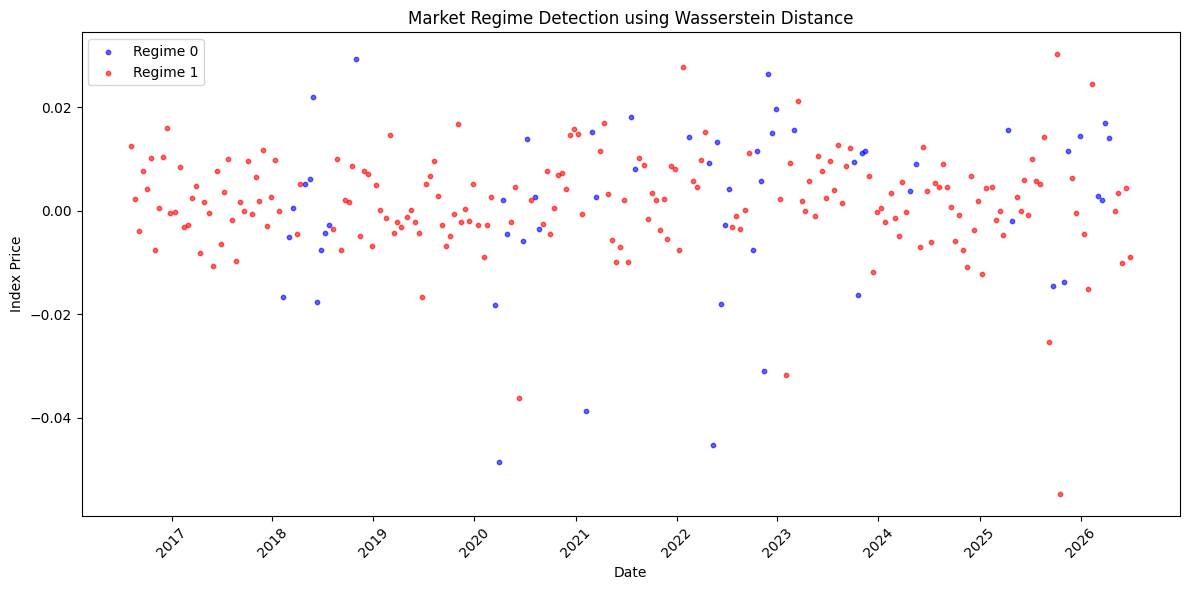

Regime 0: Mean=-0.0022, Std=0.0191, Count=55 windows
Regime 1: Mean=0.0012, Std=0.0085, Count=193 windows


In [5]:
from scipy.stats import wasserstein_distance
from sklearn.manifold import MDS
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt


vnindex_close = df.close['VNINDEX']

# Calculate daily returns
daily_returns = vnindex_close.pct_change().dropna()

# Calculate cumulative returns
cumulative_returns = (1 + daily_returns).cumprod() - 1

# Create rolling windows
window_size = 20
step_size = 10
segments = []
segment_dates = []

for i in range(0, len(daily_returns) - window_size, step_size):
    segments.append(daily_returns[i:i + window_size])
    # Store the end date of each window for plotting
    segment_dates.append(daily_returns.index[i + window_size])

print(len(segments), len(segment_dates))
# Compute Wasserstein distance matrix
n_segments = len(segments)
distance_matrix = np.zeros((n_segments, n_segments))
for i in range(n_segments):
    for j in range(i + 1, n_segments):
        dist = wasserstein_distance(segments[i].ravel(), segments[j].ravel())
        distance_matrix[i, j] = dist
        distance_matrix[j, i] = dist

# Embed into 2D space using MDS (to visualize)
mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42)
embedding = mds.fit_transform(distance_matrix)

# Cluster in embedded space
n_clusters = 2
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
labels = kmeans.fit_predict(embedding)

# Visualize clusters
plt.figure(figsize=(12, 6))
colors = ['blue', 'red', 'green', 'orange']

for cluster in range(n_clusters):
    cluster_mask = (labels == cluster)
    cluster_dates = [segment_dates[i] for i in range(len(segment_dates)) if cluster_mask[i]]
    cluster_prices = daily_returns.loc[cluster_dates]
    plt.scatter(cluster_dates, cluster_prices, 
                c=colors[cluster], s=10, alpha=0.6, label=f'Regime {cluster}')

plt.legend()
plt.title('Market Regime Detection using Wasserstein Distance')
plt.ylabel('Index Price')
plt.xlabel('Date')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Print cluster statistics
for cluster in range(n_clusters):
    cluster_segments = [segments[i] for i in range(len(segments)) if labels[i] == cluster]
    all_returns = np.concatenate(cluster_segments)
    print(f"Regime {cluster}: Mean={all_returns.mean():.4f}, Std={all_returns.std():.4f}, "
          f"Count={len(cluster_segments)} windows")

Note: Extended last regime (Crisis (High Vol)) from 2026-06-29 to 2026-07-08


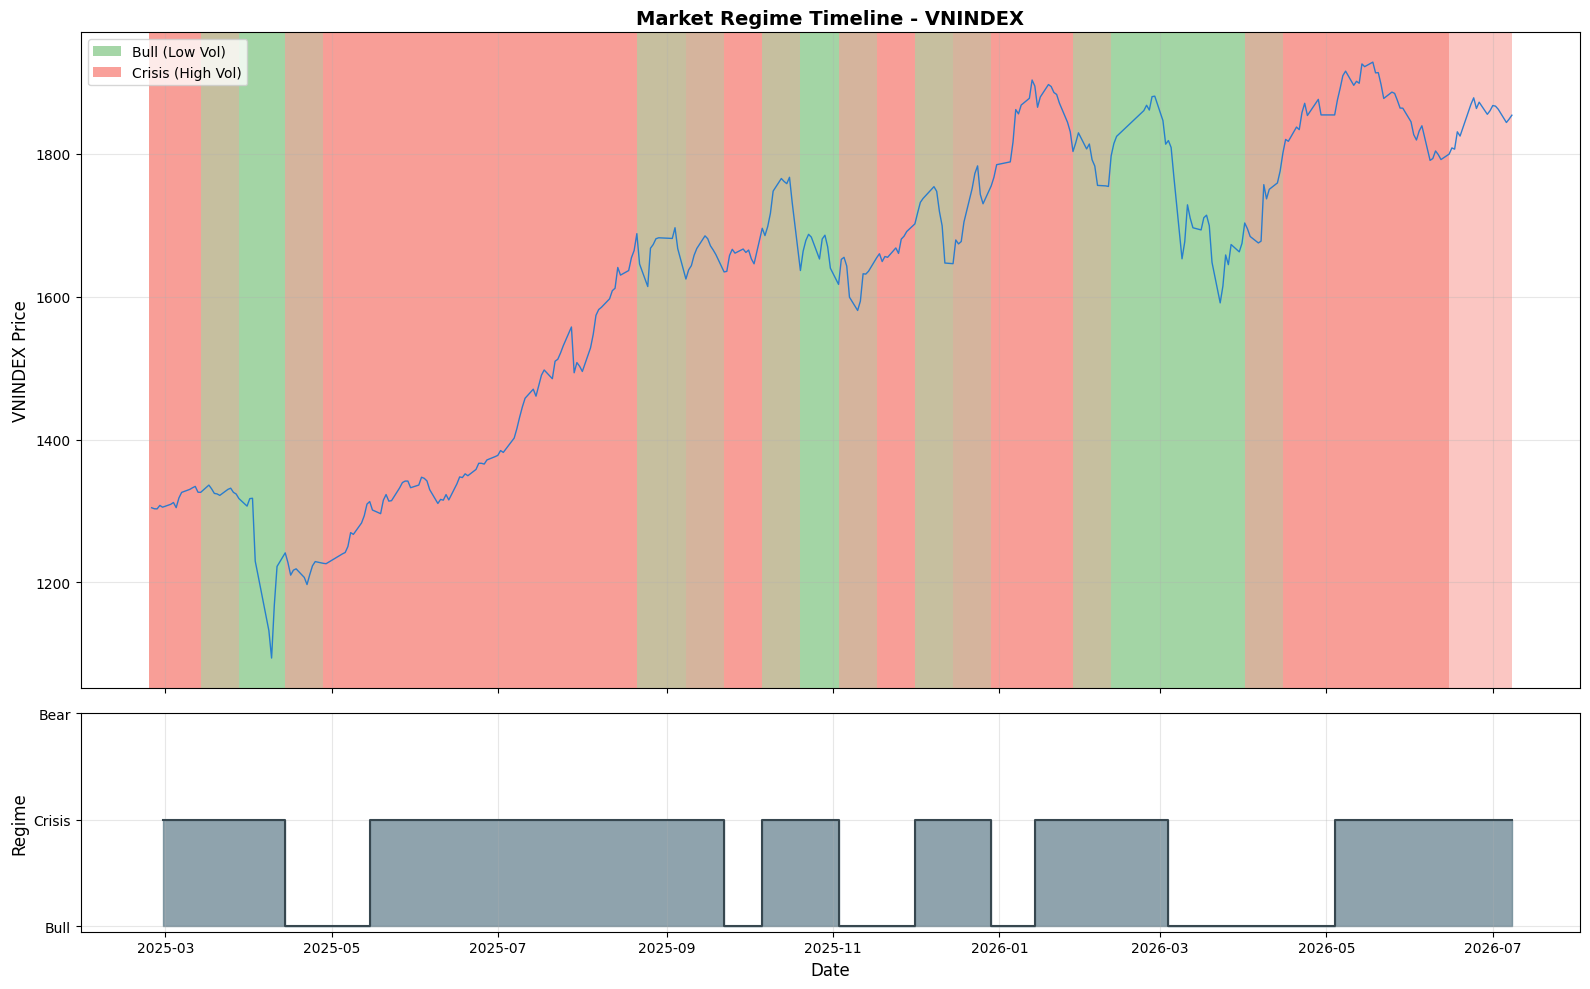


REGIME SUMMARY (Last 500 days)
Bull (Low Vol)      : Mean=-0.12%, Std=2.03%, Count= 10 windows (29.4%)
Crisis (High Vol)   : Mean=+0.22%, Std=0.95%, Count= 24 windows (70.6%)
Last day of data:  2026-07-08 00:00:00


In [6]:
# Plot regime timeline chart - Last 500 days only
last_n_days = 500
cutoff_date = vnindex_close.index[-1] - pd.Timedelta(days=last_n_days)

# Filter data for last 500 days
vnindex_close_filtered = vnindex_close[vnindex_close.index >= cutoff_date]
daily_returns_filtered = daily_returns[daily_returns.index >= cutoff_date]

# Filter segment dates and labels for last 500 days
filtered_indices = [i for i, d in enumerate(segment_dates) if d >= cutoff_date]
segment_dates_filtered = [segment_dates[i] for i in filtered_indices]
labels_filtered = [labels[i] for i in filtered_indices]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), sharex=True, 
                                gridspec_kw={'height_ratios': [3, 1]})

# Define regime colors and names based on statistics
regime_colors = {0: '#4CAF50', 1: '#F44336', 2: '#FF9800'}  # Green=Bull, Red=Crisis, Orange=Bear
regime_names = {0: 'Bull (Low Vol)', 1: 'Crisis (High Vol)', 2: 'Bear'}

# Top plot: Price with regime background
ax1.plot(vnindex_close_filtered.index, vnindex_close_filtered.values, color='#1976D2', linewidth=1, alpha=0.9)

# Add colored background for each regime period
for i, (date, label) in enumerate(zip(segment_dates_filtered, labels_filtered)):
    # Get start date of the window
    orig_idx = filtered_indices[i]
    start_idx = max(0, orig_idx * step_size)
    start_date = max(daily_returns.index[start_idx], cutoff_date)
    end_date = date
    
    ax1.axvspan(start_date, end_date, alpha=0.3, color=regime_colors[label], linewidth=0)

# Extend the last regime to cover remaining days (forward-fill)
if len(segment_dates_filtered) > 0:
    last_regime_date = segment_dates_filtered[-1]
    last_regime_label = labels_filtered[-1]
    last_data_date = vnindex_close_filtered.index[-1]
    if last_data_date > last_regime_date:
        ax1.axvspan(last_regime_date, last_data_date, alpha=0.3, 
                    color=regime_colors[last_regime_label], linewidth=0)
        print(f"Note: Extended last regime ({regime_names[last_regime_label]}) from {last_regime_date.date()} to {last_data_date.date()}")

ax1.set_ylabel('VNINDEX Price', fontsize=12)
ax1.set_title('Market Regime Timeline - VNINDEX', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Create legend for regimes
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=regime_colors[i], alpha=0.5, label=regime_names[i]) 
                   for i in range(n_clusters)]
ax1.legend(handles=legend_elements, loc='upper left')

# Bottom plot: Regime indicator as step chart
# Extend to last data date by appending the last regime
regime_series = pd.Series(labels_filtered, index=segment_dates_filtered)
if len(regime_series) > 0 and vnindex_close_filtered.index[-1] > regime_series.index[-1]:
    regime_series = pd.concat([regime_series, pd.Series([labels_filtered[-1]], index=[vnindex_close_filtered.index[-1]])])

ax2.fill_between(regime_series.index, regime_series.values, step='post', alpha=0.7, color='#607D8B')
ax2.step(regime_series.index, regime_series.values, where='post', color='#37474F', linewidth=1.5)

ax2.set_ylabel('Regime', fontsize=12)
ax2.set_xlabel('Date', fontsize=12)
ax2.set_yticks([0, 1, 2])
ax2.set_yticklabels(['Bull', 'Crisis', 'Bear'])
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Also create a summary table for last 500 days
print("\n" + "="*60)
print(f"REGIME SUMMARY (Last {last_n_days} days)")
print("="*60)
for cluster in range(n_clusters):
    cluster_indices = [filtered_indices[i] for i in range(len(filtered_indices)) if labels_filtered[i] == cluster]
    cluster_segments = [segments[idx] for idx in cluster_indices]
    if cluster_segments:
        all_returns = np.concatenate(cluster_segments)
        pct = len(cluster_segments) / len(labels_filtered) * 100
        print(f"{regime_names[cluster]:20s}: Mean={all_returns.mean()*100:+.2f}%, "
              f"Std={all_returns.std()*100:.2f}%, Count={len(cluster_segments):3d} windows ({pct:.1f}%)")
    else:
        print(f"{regime_names[cluster]:20s}: No windows in this period")
print("Last day of data: ", vnindex_close.index[-1])

In [7]:
# =============================================================================
# IMPROVED REGIME DETECTION WITH MULTIPLE FEATURES
# =============================================================================
from scipy.stats import skew, kurtosis
from sklearn.preprocessing import StandardScaler

# -----------------------------------------------------------------------------
# 1. Calculate McClellan Summation Index (Market Breadth)
# -----------------------------------------------------------------------------
# McClellan requires advance/decline data. We'll simulate using stock breadth.
close_prices = df.close.dropna(axis=1, how='all')

# Calculate advancing vs declining stocks
advances = (close_prices.pct_change() > 0).sum(axis=1)
declines = (close_prices.pct_change() < 0).sum(axis=1)
advance_decline = advances - declines

# McClellan Oscillator = EMA(19) - EMA(39) of Advance-Decline
ema_19 = advance_decline.ewm(span=19, adjust=False).mean()
ema_39 = advance_decline.ewm(span=39, adjust=False).mean()
mcclellan_oscillator = ema_19 - ema_39

# McClellan Summation Index = Cumulative sum of McClellan Oscillator
mcclellan_summation = mcclellan_oscillator.cumsum()

# Normalize for easier interpretation
mcclellan_summation_norm = (mcclellan_summation - mcclellan_summation.rolling(252).mean()) / mcclellan_summation.rolling(252).std()

print("McClellan Summation Index calculated!")
print(f"Current value: {mcclellan_summation.iloc[-1]:.2f}")

# -----------------------------------------------------------------------------
# 2. Calculate Additional Indicators
# -----------------------------------------------------------------------------
# Volatility (20-day rolling std)
volatility = daily_returns.rolling(20).std()

# Trend strength (20-day momentum)
momentum = vnindex_close.pct_change(20)

# Market breadth ratio
breadth_ratio = advances / (advances + declines + 1e-6)

# RSI of the index
def calculate_rsi(prices, period=14):
    delta = prices.diff()
    gain = delta.where(delta > 0, 0).rolling(period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(period).mean()
    rs = gain / (loss + 1e-6)
    return 100 - (100 / (1 + rs))

rsi = calculate_rsi(vnindex_close)

# -----------------------------------------------------------------------------
# 3. Extract Features for Each Window
# -----------------------------------------------------------------------------
window_size = 20
step_size = 10
feature_list = []
feature_dates = []

for i in range(0, len(daily_returns) - window_size, step_size):
    end_idx = i + window_size
    end_date = daily_returns.index[end_idx]
    
    # Return distribution features
    window_returns = daily_returns.iloc[i:end_idx].values
    
    features = {
        # Distribution features
        'mean_return': np.mean(window_returns),
        'volatility': np.std(window_returns),
        'skewness': skew(window_returns),
        'kurtosis': kurtosis(window_returns),
        
        # Technical indicators (end of window values)
        'mcclellan_sum': mcclellan_summation_norm.iloc[end_idx] if end_idx < len(mcclellan_summation_norm) else np.nan,
        'momentum': momentum.iloc[end_idx] if end_idx < len(momentum) else np.nan,
        'breadth': breadth_ratio.iloc[end_idx] if end_idx < len(breadth_ratio) else np.nan,
        'rsi': rsi.iloc[end_idx] if end_idx < len(rsi) else np.nan,
        
        # Trend features
        'trend_direction': 1 if window_returns.mean() > 0 else -1,
        'vol_regime': volatility.iloc[end_idx] if end_idx < len(volatility) else np.nan,
    }
    
    feature_list.append(features)
    feature_dates.append(end_date)

# Convert to DataFrame
features_df = pd.DataFrame(feature_list, index=feature_dates)
features_df = features_df.dropna()

print(f"\nFeature matrix shape: {features_df.shape}")
print(f"Features: {list(features_df.columns)}")
features_df.tail()


McClellan Summation Index calculated!
Current value: -227.98

Feature matrix shape: (224, 10)
Features: ['mean_return', 'volatility', 'skewness', 'kurtosis', 'mcclellan_sum', 'momentum', 'breadth', 'rsi', 'trend_direction', 'vol_regime']


,mean_return,volatility,skewness,kurtosis,mcclellan_sum,momentum,breadth,rsi,trend_direction,vol_regime
2026-05-04,0.005191,0.013014,1.375697,2.855020,-0.900801,0.107263,0.631902,71.440498,1,0.013101
2026-05-18,0.003991,0.008158,-0.471737,-1.005006,-1.171619,0.082195,0.367232,66.493941,1,0.008026
2026-06-01,0.000277,0.006936,0.230584,-0.758420,-1.529829,0.005064,0.308571,37.541834,1,0.007491
2026-06-15,-0.003466,0.007509,-1.131954,1.860247,-1.696187,-0.067626,0.356688,20.601792,-1,0.007752
2026-06-29,0.000269,0.009336,-0.768727,1.393586,-1.411910,0.004518,0.357143,76.989911,1,0.009518


In [8]:
# =============================================================================
# 4. Cluster on Multi-Feature Space
# =============================================================================
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

# Standardize features (important for clustering!)
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features_df)

# Try different numbers of clusters and evaluate
print("Evaluating optimal number of clusters...")
silhouette_scores = []
for k in range(2, 6):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_temp = kmeans.fit_predict(features_scaled)
    score = silhouette_score(features_scaled, labels_temp)
    silhouette_scores.append((k, score))
    print(f"  k={k}: Silhouette Score = {score:.4f}")

best_k = max(silhouette_scores, key=lambda x: x[1])[0]
print(f"\nOptimal clusters: {best_k}")

# Final clustering with optimal k
n_clusters_improved = best_k
kmeans_improved = KMeans(n_clusters=n_clusters_improved, random_state=42, n_init=10)
labels_improved = kmeans_improved.fit_predict(features_scaled)

# Alternative: Gaussian Mixture Model (soft clustering, handles elliptical clusters better)
gmm = GaussianMixture(n_components=n_clusters_improved, random_state=42, covariance_type='full')
labels_gmm = gmm.fit_predict(features_scaled)
gmm_probs = gmm.predict_proba(features_scaled)

print(f"\nGMM cluster probabilities shape: {gmm_probs.shape}")

# Add labels to features dataframe
features_df['regime_kmeans'] = labels_improved
features_df['regime_gmm'] = labels_gmm

# Analyze regime characteristics
print("\n" + "="*70)
print("REGIME CHARACTERISTICS (Feature-Based)")
print("="*70)
for regime in range(n_clusters_improved):
    mask = features_df['regime_kmeans'] == regime
    regime_data = features_df[mask]
    print(f"\nRegime {regime} ({mask.sum()} windows):")
    print(f"  Mean Return:    {regime_data['mean_return'].mean()*100:+.3f}%")
    print(f"  Volatility:     {regime_data['volatility'].mean()*100:.3f}%")
    print(f"  McClellan Sum:  {regime_data['mcclellan_sum'].mean():+.2f}")
    print(f"  Momentum:       {regime_data['momentum'].mean()*100:+.2f}%")
    print(f"  Breadth:        {regime_data['breadth'].mean():.2%}")
    print(f"  RSI:            {regime_data['rsi'].mean():.1f}")


Evaluating optimal number of clusters...
  k=2: Silhouette Score = 0.2834
  k=3: Silhouette Score = 0.2228
  k=4: Silhouette Score = 0.2306
  k=5: Silhouette Score = 0.1702

Optimal clusters: 2

GMM cluster probabilities shape: (224, 2)

REGIME CHARACTERISTICS (Feature-Based)

Regime 0 (86 windows):
  Mean Return:    -0.230%
  Volatility:     1.347%
  McClellan Sum:  -0.83
  Momentum:       -4.61%
  Breadth:        43.20%
  RSI:            39.7

Regime 1 (138 windows):
  Mean Return:    +0.218%
  Volatility:     0.888%
  McClellan Sum:  +0.30
  Momentum:       +4.42%
  Breadth:        48.88%
  RSI:            64.8


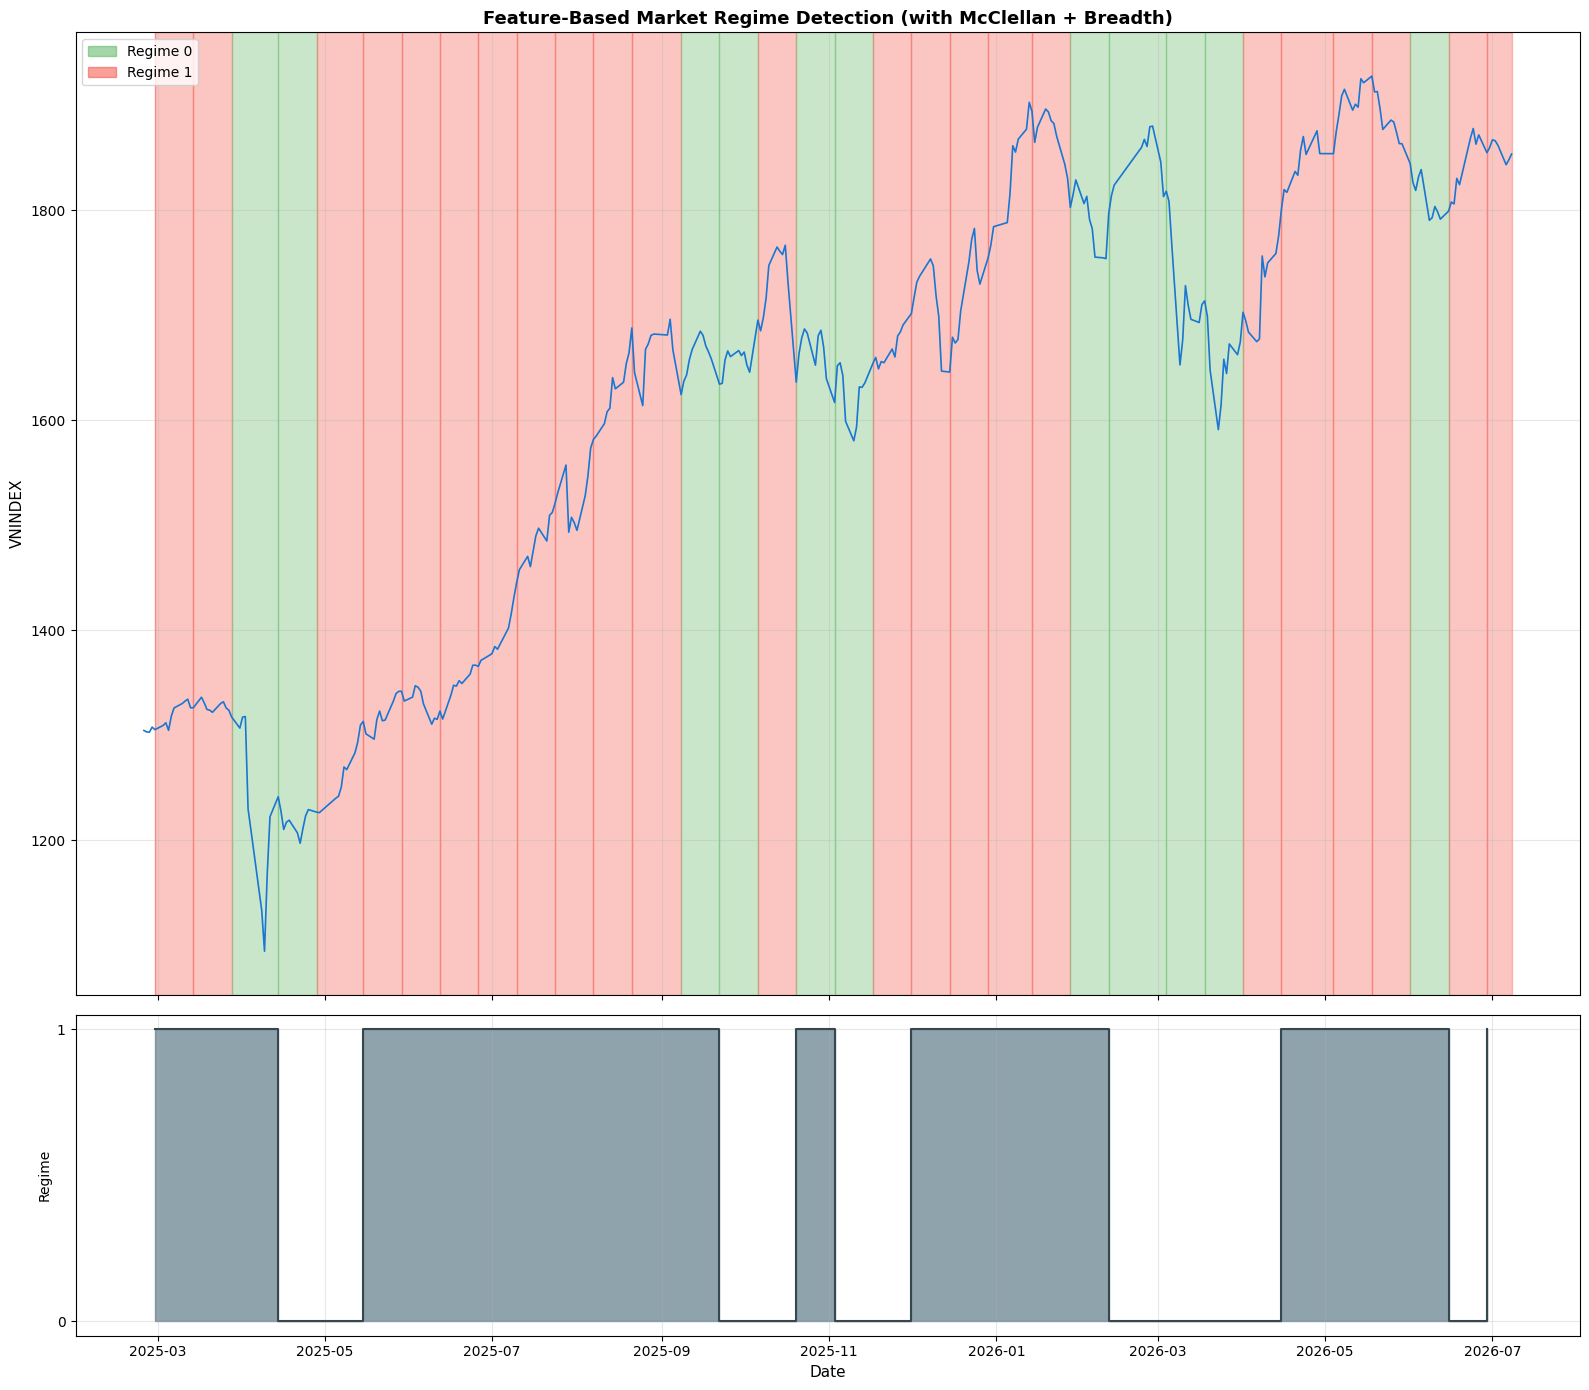


Current Regime: 1
Current McClellan: -1.27
Current Breadth: 66.87%


In [9]:
# =============================================================================
# 5. Visualize Improved Regime Detection (Last 500 days)
# =============================================================================
last_n_days = 500
cutoff_date = vnindex_close.index[-1] - pd.Timedelta(days=last_n_days)

# Filter features_df for visualization
features_filtered = features_df[features_df.index >= cutoff_date].copy()

fig, axes = plt.subplots(2, 1, figsize=(16, 14), sharex=True,
                          gridspec_kw={'height_ratios': [3, 1]})

# Color scheme for regimes
regime_colors_improved = ['#4CAF50', '#F44336', '#FF9800', '#2196F3', '#9C27B0']

# 1. Price with regime background
ax1 = axes[0]
vnindex_filtered = vnindex_close[vnindex_close.index >= cutoff_date]
ax1.plot(vnindex_filtered.index, vnindex_filtered.values, color='#1976D2', linewidth=1.2)

# Add regime backgrounds
prev_date = features_filtered.index[0]
for date, row in features_filtered.iterrows():
    regime = int(row['regime_kmeans'])
    ax1.axvspan(prev_date, date, alpha=0.3, color=regime_colors_improved[regime])
    prev_date = date

# Extend to last date
if features_filtered.index[-1] < vnindex_filtered.index[-1]:
    last_regime = int(features_filtered['regime_kmeans'].iloc[-1])
    ax1.axvspan(features_filtered.index[-1], vnindex_filtered.index[-1], 
                alpha=0.3, color=regime_colors_improved[last_regime])

ax1.set_ylabel('VNINDEX', fontsize=11)
ax1.set_title('Feature-Based Market Regime Detection (with McClellan + Breadth)', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Legend
from matplotlib.patches import Patch
legend_patches = [Patch(color=regime_colors_improved[i], alpha=0.5, label=f'Regime {i}') 
                  for i in range(n_clusters_improved)]
ax1.legend(handles=legend_patches, loc='upper left')

# 4. Regime indicator
ax4 = axes[1]
regime_series = features_filtered['regime_kmeans']
ax4.fill_between(regime_series.index, regime_series.values, step='post', alpha=0.7, color='#607D8B')
ax4.step(regime_series.index, regime_series.values, where='post', color='#37474F', linewidth=1.5)
ax4.set_ylabel('Regime', fontsize=10)
ax4.set_xlabel('Date', fontsize=11)
ax4.set_yticks(range(n_clusters_improved))
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nCurrent Regime: {features_filtered['regime_kmeans'].iloc[-1]}")
print(f"Current McClellan: {mcclellan_summation_norm.iloc[-1]:.2f}")
print(f"Current Breadth: {breadth_ratio.iloc[-1]:.2%}")


In [10]:
# =============================================================================
# REAL-TIME REGIME DETECTION (Production-Ready Approach)
# =============================================================================
# The key insight: Train on HISTORICAL data, apply to CURRENT data without refitting

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.stats import skew, kurtosis
import pickle

# -----------------------------------------------------------------------------
# Step 1: Define the training period (e.g., first 80% of data)
# -----------------------------------------------------------------------------
train_ratio = 0.8
train_end_idx = int(len(features_df) * train_ratio)

train_data = features_df.iloc[:train_end_idx].copy()
test_data = features_df.iloc[train_end_idx:].copy()  # "Future" data for validation

print(f"Training period: {train_data.index[0].date()} to {train_data.index[-1].date()}")
print(f"Test period:     {test_data.index[0].date()} to {test_data.index[-1].date()}")
print(f"Training samples: {len(train_data)}, Test samples: {len(test_data)}")

# -----------------------------------------------------------------------------
# Step 2: Fit scaler and clusterer on TRAINING data only
# -----------------------------------------------------------------------------
feature_cols = ['mean_return', 'volatility', 'skewness', 'kurtosis', 
                'mcclellan_sum', 'momentum', 'breadth', 'rsi', 'vol_regime']

# Fit scaler on training data
scaler_realtime = StandardScaler()
train_scaled = scaler_realtime.fit_transform(train_data[feature_cols])

# Fit KMeans on training data
n_clusters_realtime = 3
kmeans_realtime = KMeans(n_clusters=n_clusters_realtime, random_state=42, n_init=10)
kmeans_realtime.fit(train_scaled)

train_labels = kmeans_realtime.labels_
print(f"\nCluster distribution in training: {np.bincount(train_labels)}")

# -----------------------------------------------------------------------------
# Step 3: Apply to test data WITHOUT refitting (real-time simulation)
# -----------------------------------------------------------------------------
test_scaled = scaler_realtime.transform(test_data[feature_cols])  # transform, not fit_transform!
test_labels = kmeans_realtime.predict(test_scaled)  # predict, not fit_predict!

print(f"Cluster distribution in test: {np.bincount(test_labels)}")

# Add labels
train_data['regime_realtime'] = train_labels
test_data['regime_realtime'] = test_labels

# Combine for visualization
all_data_realtime = pd.concat([train_data, test_data])

# -----------------------------------------------------------------------------
# Step 4: Validate - do regimes have consistent characteristics?
# -----------------------------------------------------------------------------
print("\n" + "="*70)
print("REGIME CONSISTENCY CHECK")
print("="*70)
print("\nTraining Period Characteristics:")
for r in range(n_clusters_realtime):
    mask = train_data['regime_realtime'] == r
    if mask.sum() > 0:
        print(f"  Regime {r}: Mean={train_data.loc[mask, 'mean_return'].mean()*100:+.2f}%, "
              f"Vol={train_data.loc[mask, 'volatility'].mean()*100:.2f}%, "
              f"Count={mask.sum()}")

print("\nTest Period Characteristics (should be similar!):")
for r in range(n_clusters_realtime):
    mask = test_data['regime_realtime'] == r
    if mask.sum() > 0:
        print(f"  Regime {r}: Mean={test_data.loc[mask, 'mean_return'].mean()*100:+.2f}%, "
              f"Vol={test_data.loc[mask, 'volatility'].mean()*100:.2f}%, "
              f"Count={mask.sum()}")

# -----------------------------------------------------------------------------
# Current regime detection
# -----------------------------------------------------------------------------
current_features = features_df[feature_cols].iloc[-1:].values
current_scaled = scaler_realtime.transform(current_features)
current_regime = kmeans_realtime.predict(current_scaled)[0]

print("\n" + "="*70)
print(f"🎯 CURRENT MARKET REGIME: {current_regime}")
print("="*70)


Training period: 2017-07-25 to 2024-09-06
Test period:     2024-09-20 to 2026-06-29
Training samples: 179, Test samples: 45

Cluster distribution in training: [ 42 102  35]
Cluster distribution in test: [ 7 33  5]

REGIME CONSISTENCY CHECK

Training Period Characteristics:
  Regime 0: Mean=-0.35%, Vol=1.69%, Count=42
  Regime 1: Mean=+0.16%, Vol=0.77%, Count=102
  Regime 2: Mean=+0.13%, Vol=1.21%, Count=35

Test Period Characteristics (should be similar!):
  Regime 0: Mean=-0.31%, Vol=1.92%, Count=7
  Regime 1: Mean=+0.16%, Vol=0.82%, Count=33
  Regime 2: Mean=+0.19%, Vol=1.26%, Count=5

🎯 CURRENT MARKET REGIME: 1


In [11]:
# =============================================================================
# PRODUCTION: Save model for real-time use
# =============================================================================

# Save the trained model and scaler
model_artifacts = {
    'scaler': scaler_realtime,
    'kmeans': kmeans_realtime,
    'feature_cols': feature_cols,
    'n_clusters': n_clusters_realtime,
    'training_end_date': train_data.index[-1],
    'regime_descriptions': {
        # You should update these based on your analysis
        0: 'Unknown - check characteristics',
        1: 'Unknown - check characteristics', 
        2: 'Unknown - check characteristics',
    }
}

# Save to file
with open('regime_model.pkl', 'wb') as f:
    pickle.dump(model_artifacts, f)
print("Model saved to regime_model.pkl")

# -----------------------------------------------------------------------------
# Example: How to use in production
# -----------------------------------------------------------------------------
print("\n" + "="*70)
print("PRODUCTION USAGE EXAMPLE")
print("="*70)
print("""
# Load model
with open('regime_model.pkl', 'rb') as f:
    model = pickle.load(f)

# Calculate features for today's window (last 20 days)
today_features = {
    'mean_return': daily_returns[-20:].mean(),
    'volatility': daily_returns[-20:].std(),
    'skewness': skew(daily_returns[-20:]),
    'kurtosis': kurtosis(daily_returns[-20:]),
    'mcclellan_sum': mcclellan_summation_norm.iloc[-1],
    'momentum': momentum.iloc[-1],
    'breadth': breadth_ratio.iloc[-1],
    'rsi': rsi.iloc[-1],
    'vol_regime': volatility.iloc[-1],
}

# Predict
features_array = np.array([[today_features[col] for col in model['feature_cols']]])
features_scaled = model['scaler'].transform(features_array)
current_regime = model['kmeans'].predict(features_scaled)[0]
print(f"Current Regime: {current_regime}")
""")


Model saved to regime_model.pkl

PRODUCTION USAGE EXAMPLE

# Load model
with open('regime_model.pkl', 'rb') as f:
    model = pickle.load(f)

# Calculate features for today's window (last 20 days)
today_features = {
    'mean_return': daily_returns[-20:].mean(),
    'volatility': daily_returns[-20:].std(),
    'skewness': skew(daily_returns[-20:]),
    'kurtosis': kurtosis(daily_returns[-20:]),
    'mcclellan_sum': mcclellan_summation_norm.iloc[-1],
    'momentum': momentum.iloc[-1],
    'breadth': breadth_ratio.iloc[-1],
    'rsi': rsi.iloc[-1],
    'vol_regime': volatility.iloc[-1],
}

# Predict
features_array = np.array([[today_features[col] for col in model['feature_cols']]])
features_scaled = model['scaler'].transform(features_array)
current_regime = model['kmeans'].predict(features_scaled)[0]
print(f"Current Regime: {current_regime}")



# DEEPTIME TICA + HMM REGIME DETECTION (VNINDEX)
**Adapted from**: SPY/VIX market regime detection with deeptime  
**Key idea**: TICA finds *slow-varying* directions → HMM models temporal regime persistence with transition probabilities  
**VNINDEX adaptation**: No official VIX → realized volatility family as proxy (RV-10, RV-5, vol term structure, vol-of-vol)  
**Regime labels**: Risk-On / Risk-On (Elevated Vol) / Risk-Off — aligned with practical risk management language

In [12]:
# =============================================================================
# §1 — VIX-PROXY FEATURE ENGINEERING
# Vietnam has no official VIX → build realized-volatility family as substitute
# Best params from §7 grid search: vol_w=30, lag=60
# =============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from deeptime.decomposition import TICA
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from scipy.stats import skew, kurtosis

# ── Tuned vol window (from §7 grid search) ────────────────────────────────────
VOL_W = 10   # best vol_window

# VNINDEX daily returns (reuse vnindex_close from earlier cells)
vnindex_ret = vnindex_close.pct_change().dropna()

# ── Realized-volatility family (VIX analog) ──────────────────────────────────
ann = np.sqrt(252)
rv5  = vnindex_ret.rolling(max(VOL_W // 2, 5)).std() * ann * 100   # short RV
rv20 = vnindex_ret.rolling(VOL_W).std()               * ann * 100   # main VIX proxy
rv60 = vnindex_ret.rolling(VOL_W * 3).std()           * ann * 100   # long RV

# Vol term structure: short / long  (VIX/VXV analog — contango vs backwardation)
vol_ts = rv5 / (rv60 + 1e-8)

# Vol-of-vol: how much does RV itself fluctuate? (fear-of-fear indicator)
vov = rv20.rolling(VOL_W).std()

# ── Return / momentum features ────────────────────────────────────────────────
ret1  = vnindex_ret
mom5  = vnindex_close.pct_change(5)
mom20 = vnindex_close.pct_change(20)

# ── Return distribution features (rolling window) ────────────────────────────
skew20 = vnindex_ret.rolling(VOL_W).apply(skew,     raw=True)
kurt20 = vnindex_ret.rolling(VOL_W).apply(kurtosis, raw=True)

# ── Combine ───────────────────────────────────────────────────────────────────
tica_features_raw = pd.DataFrame({
    'ret1d'   : ret1,
    'rv5'     : rv5,
    'rv20'    : rv20,       # main VIX proxy (window=VOL_W)
    'rv60'    : rv60,       # long RV (window=VOL_W*3)
    'vol_ts'  : vol_ts,
    'vov'     : vov,
    'mom5'    : mom5,
    'mom20'   : mom20,
    'skew20'  : skew20,
    'kurt20'  : kurt20,
}, index=vnindex_ret.index).dropna()

print(f"VOL_W={VOL_W}  (rv_short={max(VOL_W//2,5)}, rv_main={VOL_W}, rv_long={VOL_W*3})")
print(f"Feature matrix : {tica_features_raw.shape}")
print(f"Date range     : {tica_features_raw.index[0].date()} → {tica_features_raw.index[-1].date()}")
tica_features_raw.describe().round(4)

VOL_W=10  (rv_short=5, rv_main=10, rv_long=30)
Feature matrix : (2469, 10)
Date range     : 2016-08-22 → 2026-07-08


,ret1d,rv5,rv20,rv60,vol_ts,vov,mom5,mom20,skew20,kurt20
count,2469.0000,2469.0000,2469.0000,2469.0000,2469.0000,2469.0000,2469.0000,2469.0000,2469.0000,2469.0000
mean,0.0005,15.0576,15.9241,16.8686,0.9094,3.0401,0.0025,0.0102,-0.1616,-0.2175
std,0.0118,10.6834,9.5246,8.0759,0.4149,2.6966,0.0279,0.0571,0.7031,0.9695
min,-0.0668,1.6234,3.3240,5.4132,0.1036,0.1342,-0.1693,-0.2753,-2.4066,-1.7753
25%,-0.0041,8.1943,9.4352,10.4560,0.6005,1.3121,-0.0101,-0.0168,-0.5815,-0.8913
50%,0.0014,11.7012,12.7108,14.6102,0.8620,2.1102,0.0054,0.0134,-0.1397,-0.4591
75%,0.0063,18.0038,20.1846,21.1987,1.1473,3.8272,0.0184,0.0440,0.2584,0.2138
max,0.0677,87.8821,68.6969,44.3290,2.4263,24.1156,0.1290,0.1727,2.2227,4.3355


In [20]:
# =============================================================================
# §2 — TICA: Time-lagged Independent Component Analysis (deeptime)
#
# TICA maximises autocorrelation at lag τ → singular vectors point along the
# *slowest* directions of the data. Regimes are slow by nature (days–months),
# so these slow components cleanly separate bull/bear/crisis clusters.
# =============================================================================
TICA_LAG   = 20 
N_IC       = 3    # slow independent components to keep

# Standardise (TICA is not scale-invariant)
scaler_tica = StandardScaler()
X_std = scaler_tica.fit_transform(tica_features_raw.values)

# Fit TICA
tica_est   = TICA(lagtime=TICA_LAG, dim=N_IC)
tica_model = tica_est.fit(X_std).fetch_model()
X_ic       = tica_model.transform(X_std)

ic_df = pd.DataFrame(
    X_ic,
    index=tica_features_raw.index,
    columns=[f'IC{i+1}' for i in range(N_IC)]
)

# ── Implied timescales ────────────────────────────────────────────────────────
svs = tica_model.singular_values[:N_IC]
print(f"TICA params: lagtime={TICA_LAG}, dim={N_IC}, vol_w={VOL_W}")
print(f"\n{'Component':<12} {'Sing. Value':>12} {'Timescale (days)':>18}")
print("-" * 44)
for i, sv in enumerate(svs):
    ts = -TICA_LAG / np.log(np.clip(abs(sv), 1e-10, 1 - 1e-10))
    print(f"IC{i+1:<9} {sv:>12.4f} {ts:>18.1f}")

# ── Feature loadings via feature-component correlation ────────────────────────
loadings = pd.DataFrame(
    tica_model.feature_component_correlation,
    index=tica_features_raw.columns,
    columns=[f'IC{i+1}' for i in range(N_IC)]
)
print(f"\nFeature → IC loadings (|correlation| with each slow component):")
print(loadings.abs().sort_values('IC1', ascending=False).round(3).to_string())
ic_df.tail()

TICA params: lagtime=20, dim=3, vol_w=10

Component     Sing. Value   Timescale (days)
--------------------------------------------
IC1               0.6332               43.8
IC2              -0.3572               19.4
IC3               0.1690               11.2

Feature → IC loadings (|correlation| with each slow component):
          IC1    IC2    IC3
rv60    0.600  0.020  0.005
rv20    0.488  0.206  0.005
rv5     0.409  0.183  0.007
vov     0.313  0.098  0.042
mom20   0.110  0.149  0.108
skew20  0.096  0.011  0.092
mom5    0.075  0.068  0.065
kurt20  0.069  0.031  0.016
ret1d   0.037  0.016  0.018
vol_ts  0.003  0.171  0.021


,IC1,IC2,IC3
date,,,
2026-07-02,-0.202282,0.033188,-0.138120
2026-07-03,-0.175222,0.025001,-0.183976
2026-07-06,-0.144323,-0.059910,0.097017
2026-07-07,-0.199779,-0.096408,0.091610
2026-07-08,-0.232269,-0.094514,0.094213


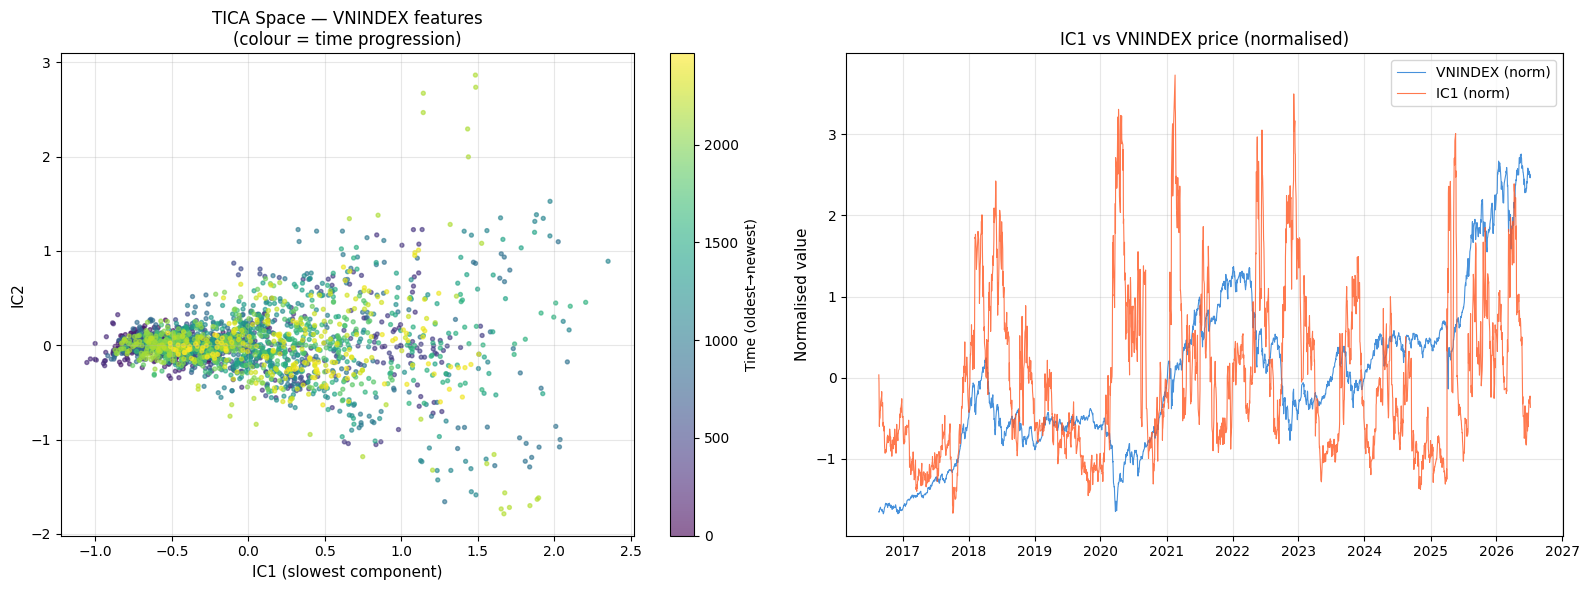

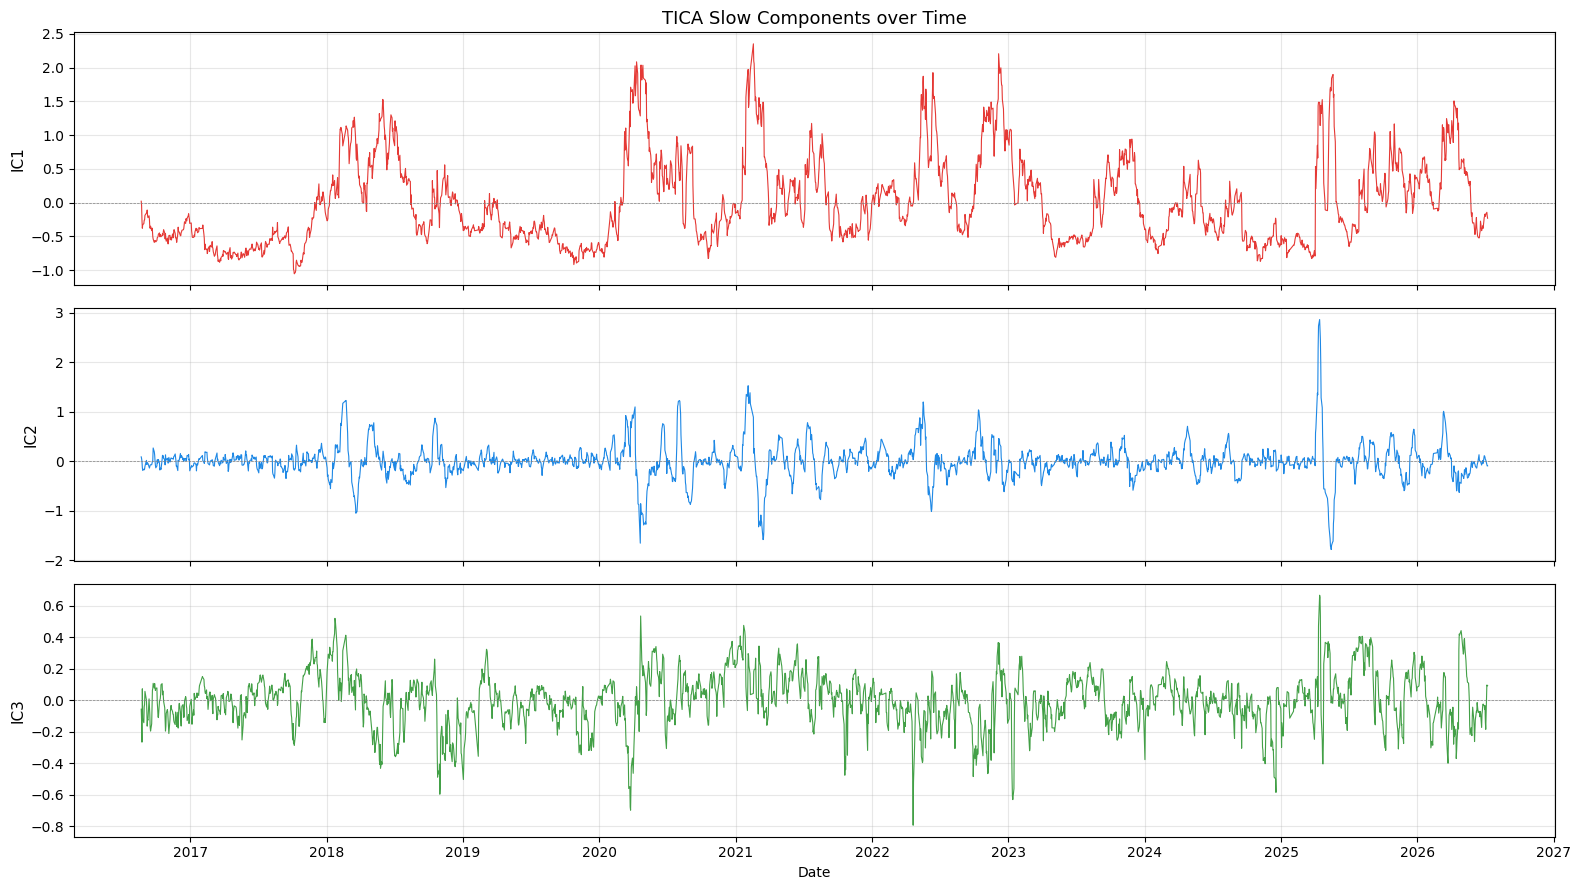

In [21]:
# =============================================================================
# §3 — VISUALISE TICA SPACE
# Scatter IC1 vs IC2 coloured by date → shows if regimes form visible clusters
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: IC1 vs IC2 coloured by date
ax = axes[0]
sc = ax.scatter(ic_df['IC1'], ic_df['IC2'],
                c=np.arange(len(ic_df)), cmap='viridis', s=8, alpha=0.6)
plt.colorbar(sc, ax=ax, label='Time (oldest→newest)')
ax.set_xlabel('IC1 (slowest component)', fontsize=11)
ax.set_ylabel('IC2', fontsize=11)
ax.set_title('TICA Space — VNINDEX features\n(colour = time progression)', fontsize=12)
ax.grid(True, alpha=0.3)

# Right: IC1 time series vs VNINDEX price (normalised)
ax2 = axes[1]
ic1_norm = (ic_df['IC1'] - ic_df['IC1'].mean()) / ic_df['IC1'].std()
vnx_norm = (vnindex_close.loc[ic_df.index] - vnindex_close.loc[ic_df.index].mean()) \
           / vnindex_close.loc[ic_df.index].std()

ax2.plot(ic_df.index, vnx_norm, color='#1976D2', linewidth=0.8, label='VNINDEX (norm)', alpha=0.8)
ax2.plot(ic_df.index, ic1_norm, color='#FF5722', linewidth=0.8, label='IC1 (norm)', alpha=0.8)
ax2.set_title('IC1 vs VNINDEX price (normalised)', fontsize=12)
ax2.set_ylabel('Normalised value', fontsize=11)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# IC time-series
fig, axes = plt.subplots(N_IC, 1, figsize=(16, 3 * N_IC), sharex=True)
colors_ic = ['#E53935', '#1E88E5', '#43A047']
for i, ax in enumerate(axes):
    ax.plot(ic_df.index, ic_df[f'IC{i+1}'], color=colors_ic[i], linewidth=0.8)
    ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
    ax.set_ylabel(f'IC{i+1}', fontsize=11)
    ax.grid(True, alpha=0.3)
axes[0].set_title('TICA Slow Components over Time', fontsize=13)
axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.show()

In [25]:
# =============================================================================
# §4 — HIDDEN MARKOV MODEL ON TICA SPACE (deeptime)
#
# deeptime's GaussianHMM operates on 1D observations → use IC1 (slowest
# component, most informative for regime transitions).
# Baum-Welch EM: enforces temporal regime persistence via transition matrix.
# Viterbi path: most likely hidden state sequence (no day-to-day flips).
# =============================================================================
import deeptime.markov.hmm as dt_hmm
from deeptime.markov.hmm import GaussianOutputModel, HiddenMarkovModel, MaximumLikelihoodHMM
from sklearn.cluster import KMeans

ic1 = X_ic[:, 0]   # slowest TICA component (1D), used for HMM observation

# ── Optional: override BIC-selected k ────────────────────────────────────────
FORCE_K = None
FORCE_K = 3

# ── BIC for 1D Gaussian HMM ───────────────────────────────────────────────────
# free params: init(k-1) + transitions(k*(k-1)) + means(k) + sigmas(k)
def hmm_bic(model, n):
    k = model.n_hidden_states
    n_params = (k - 1) + k * (k - 1) + 2 * k
    return -2 * model.likelihood + n_params * np.log(n)

def fit_hmm(k, ic1_arr, maxit=500):
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    km.fit(ic1_arr.reshape(-1, 1))
    sorted_idx = np.argsort(km.cluster_centers_.flatten())
    means  = km.cluster_centers_.flatten()[sorted_idx]
    sigmas = np.array([max(ic1_arr[km.labels_ == sorted_idx[i]].std(), 1e-3)
                       for i in range(k)])
    # sticky init: high self-transition probability
    trans = np.ones((k, k)) * (0.02 / max(k - 1, 1))
    np.fill_diagonal(trans, 1 - 0.02)
    trans /= trans.sum(axis=1, keepdims=True)
    out_model  = GaussianOutputModel(n_states=k, means=means, sigmas=sigmas)
    init_model = HiddenMarkovModel(trans, out_model)
    est = MaximumLikelihoodHMM(initial_model=init_model, lagtime=1,
                                maxit=maxit, accuracy=1e-5)
    return est.fit(ic1_arr).fetch_model()

print("HMM model selection (BIC — lower is better, fit on IC1):")
bic_scores = []
k_range = range(2, 6)
for k in k_range:
    m = fit_hmm(k, ic1)
    bic = hmm_bic(m, len(ic1))
    bic_scores.append(bic)
    print(f"  k={k}: BIC={bic:.1f}  log-lik={m.likelihood:.1f}  "
          f"timescales={np.round(m.timescales(), 1)}")

bic_best_k  = k_range[int(np.argmin(bic_scores))]
best_k_tica = FORCE_K if FORCE_K is not None else bic_best_k
print(f"\n→ BIC-best k: {bic_best_k}  |  Using k: {best_k_tica}"
      + (" (forced)" if FORCE_K else " (BIC-selected)"))

# ── Fit final HMM ─────────────────────────────────────────────────────────────
hmm_tica = fit_hmm(best_k_tica, ic1, maxit=1000)

# Hard labels (Viterbi) and soft posteriors (Baum-Welch gammas)
labels_tica = hmm_tica.hidden_state_trajectories[0]   # shape (T,)
probs_tica  = hmm_tica.state_probabilities[0]          # shape (T, k)

ic_df['regime_tica'] = labels_tica

# ── Per-regime stats ──────────────────────────────────────────────────────────
orig_feat = tica_features_raw.copy()
orig_feat['regime_tica'] = labels_tica

regime_stats = {}
for r in range(best_k_tica):
    mask = orig_feat['regime_tica'] == r
    g = orig_feat[mask]
    regime_stats[r] = {
        'ann_ret' : g['ret1d'].mean() * 252 * 100,
        'ann_vol' : g['ret1d'].std()  * np.sqrt(252) * 100,
        'avg_rv20': g['rv20'].mean(),
        'vol_ts'  : g['vol_ts'].mean(),
        'mom20'   : g['mom20'].mean() * 100,
        'count'   : mask.sum(),
        'pct'     : mask.mean() * 100,
    }

# ── Step 1: rank-based labeling sorted by ann_vol ascending ──────────────────
RANK_LABELS = {
    2: ['Risk-On',  'Risk-Off'],
    3: ['Risk-On',  'Caution',  'Risk-Off'],
    4: ['Risk-On',  'Caution',  'Risk-Off', 'Crisis'],
    5: ['Risk-On',  'Caution',  'Risk-Off', 'Crisis', 'Extreme Crisis'],
}
vol_order  = sorted(regime_stats.keys(), key=lambda r: regime_stats[r]['ann_vol'])
label_list = RANK_LABELS.get(best_k_tica, [f'Regime {i}' for i in range(best_k_tica)])

regime_meta = {}
for rank, r in enumerate(vol_order):
    regime_meta[r] = label_list[rank]

# ── Step 2: deeply negative return → Risk-Off ─────────────────────────────────
CRISIS_RET_THRESHOLD = -20.0
overridden = []
for r in range(best_k_tica):
    if regime_stats[r]['ann_ret'] < CRISIS_RET_THRESHOLD and regime_meta[r] == 'Caution':
        regime_meta[r] = 'Risk-Off'
        overridden.append(r)

if overridden:
    print(f"\n⚠  Label override: Regime(s) {overridden} → 'Risk-Off' "
          f"(ann_ret < {CRISIS_RET_THRESHOLD}%)")

# ── Step 3: positive return despite mid-vol → Risk-On (Elevated Vol) ─────────
BULL_RET_THRESHOLD = 0.0
overridden_bull = []
for r in range(best_k_tica):
    if regime_stats[r]['ann_ret'] > BULL_RET_THRESHOLD and regime_meta[r] == 'Caution':
        regime_meta[r] = 'Risk-On (Elevated Vol)'
        overridden_bull.append(r)

if overridden_bull:
    print(f"\n⚠  Label override: Regime(s) {overridden_bull} → 'Risk-On (Elevated Vol)' "
          f"(positive return, higher vol)")

# ── Transition matrix + regime summary ───────────────────────────────────────
transmat = hmm_tica.transition_model.transition_matrix
print(f"\nHMM Transition Matrix (row=from, col=to, diagonal=stickiness):")
row_labels = [f'R{r}: {regime_meta[r]}' for r in range(best_k_tica)]
trans_df = pd.DataFrame(transmat.round(3), index=row_labels,
                         columns=[f'R{r}' for r in range(best_k_tica)])
print(trans_df.to_string())

print(f"\n{'='*65}")
print("REGIME CHARACTERISTICS (TICA + HMM)  — ranked by volatility")
print(f"{'='*65}")
for r in range(best_k_tica):
    s    = regime_stats[r]
    p_ii = transmat[r, r]
    avg_dur = 1 / (1 - p_ii + 1e-10)
    print(f"\nRegime {r}  ({s['count']} days, {s['pct']:.1f}%)  avg duration ≈{avg_dur:.0f} days")
    print(f"  Ann. return : {s['ann_ret']:+.2f}%")
    print(f"  Ann. vol    : {s['ann_vol']:.2f}%")
    print(f"  RV-20 (VIX) : {s['avg_rv20']:.2f}%")
    print(f"  Vol term str: {s['vol_ts']:.3f}")
    print(f"  Mom-20      : {s['mom20']:+.2f}%")
    print(f"  → Label     : {regime_meta[r]}")

ts = hmm_tica.timescales()
print(f"\nHMM implied timescales: {np.round(ts, 1)} days")
print(f"Log-likelihood: {hmm_tica.likelihood:.4f}")

HMM model selection (BIC — lower is better, fit on IC1):
  k=2: BIC=1681.1  log-lik=-813.2  timescales=[31.1]
  k=3: BIC=258.5  log-lik=-74.5  timescales=[38.4 11.7]
  k=4: BIC=-425.3  log-lik=302.5  timescales=[43.  13.5  5.7]
  k=5: BIC=-1279.0  log-lik=772.3  timescales=[46.1 18.5 10.5  5.6]

→ BIC-best k: 5  |  Using k: 3 (forced)

⚠  Label override: Regime(s) [1] → 'Risk-On (Elevated Vol)' (positive return, higher vol)

HMM Transition Matrix (row=from, col=to, diagonal=stickiness):
                               R0     R1     R2
R0: Risk-On                 0.982  0.018  0.000
R1: Risk-On (Elevated Vol)  0.023  0.950  0.027
R2: Risk-Off                0.000  0.039  0.961

REGIME CHARACTERISTICS (TICA + HMM)  — ranked by volatility

Regime 0  (1062 days, 43.0%)  avg duration ≈56 days
  Ann. return : +27.45%
  Ann. vol    : 10.45%
  RV-20 (VIX) : 9.66%
  Vol term str: 0.931
  Mom-20      : +1.60%
  → Label     : Risk-On

Regime 1  (837 days, 33.9%)  avg duration ≈20 days
  Ann. retur

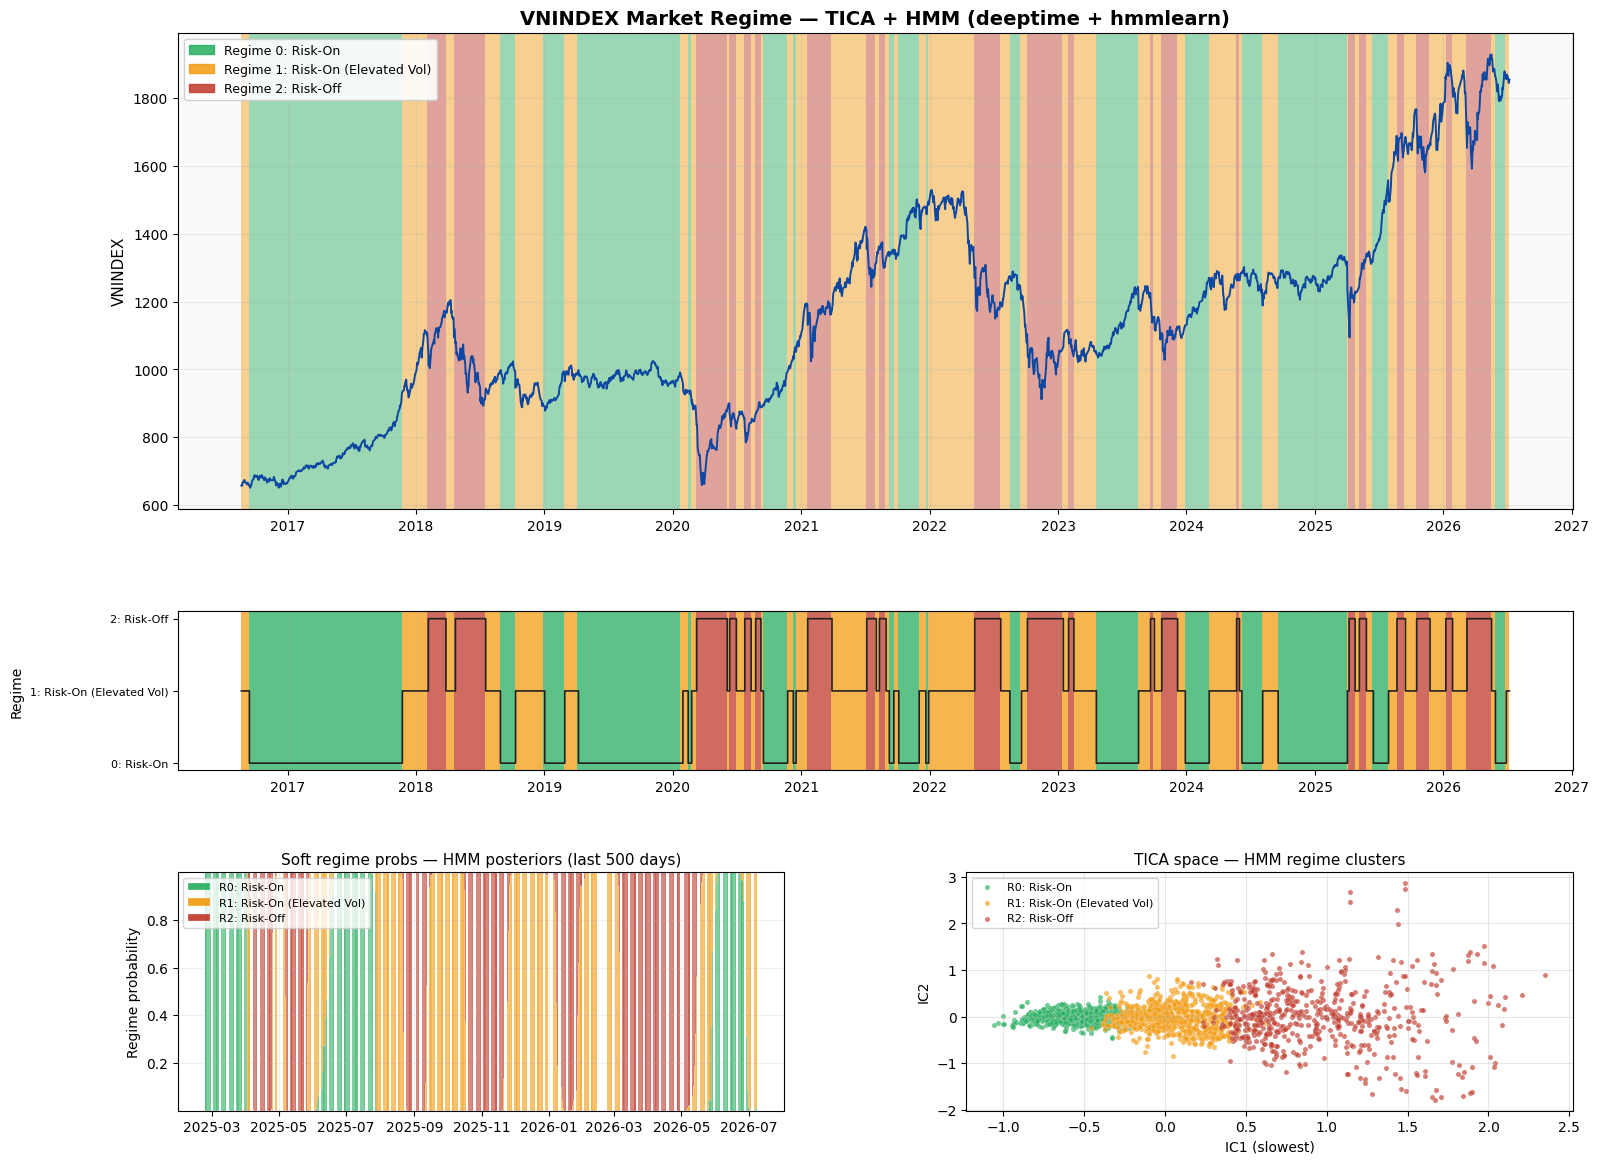


Current date : 2026-07-08
Current regime: 1 — Risk-On (Elevated Vol)
Regime probabilities today:
  Regime 0 (Risk-On): 1.6%
  Regime 1 (Risk-On (Elevated Vol)): 98.3%
  Regime 2 (Risk-Off): 0.1%


In [26]:
# =============================================================================
# §5 — REGIME TIMELINE + TICA SPACE SCATTER
# =============================================================================
PALETTES_BY_K = {
    3: {
        'Risk-On'               : '#27AE60',   # emerald green
        'Risk-On (Elevated Vol)': '#F39C12',   # amber — still bullish, elevated risk
        'Caution'               : '#E67E22',   # orange
        'Risk-Off'              : '#C0392B',   # red
        'Crisis'                : '#7B241C',   # dark red
    },
    4: {
        'Risk-On'               : '#1B5E20',   # deep green
        'Risk-On (Elevated Vol)': '#F39C12',   # amber
        'Caution'               : '#EF6C00',   # orange
        'Risk-Off'              : '#B71C1C',   # dark red
        'Crisis'                : '#7B241C',   # very dark red
    },
}
FALLBACK_BY_K = {
    3: ['#27AE60', '#F39C12', '#C0392B'],
    4: ['#1B5E20', '#F39C12', '#EF6C00', '#B71C1C'],
}

def regime_color(r):
    label = regime_meta.get(r, f'Regime {r}')
    palette = PALETTES_BY_K.get(best_k_tica, PALETTES_BY_K[3])
    if label in palette:
        return palette[label]
    fallbacks = FALLBACK_BY_K.get(best_k_tica, FALLBACK_BY_K[3])
    return fallbacks[r % len(fallbacks)]

REGIME_COLORS = [regime_color(r) for r in range(best_k_tica)]
BAND_ALPHA = 0.45 if best_k_tica == 3 else 0.38

fig = plt.figure(figsize=(18, 14))
gs  = fig.add_gridspec(3, 2, height_ratios=[3, 1, 1.5], hspace=0.35, wspace=0.3)

ax_price  = fig.add_subplot(gs[0, :])
ax_regime = fig.add_subplot(gs[1, :], sharex=ax_price)
ax_prob   = fig.add_subplot(gs[2, 0])
ax_scatter= fig.add_subplot(gs[2, 1])

# ── Top: VNINDEX price with coloured regime bands ─────────────────────────────
ax_price.set_facecolor('#FAFAFA')
ax_price.plot(vnindex_close.loc[ic_df.index], color='#0D47A1', linewidth=1.4, zorder=3)

prev = ic_df.index[0]
for date, row in ic_df.iterrows():
    r = int(row['regime_tica'])
    ax_price.axvspan(prev, date, alpha=BAND_ALPHA, color=REGIME_COLORS[r], linewidth=0, zorder=1)
    prev = date
last_r = int(ic_df['regime_tica'].iloc[-1])
ax_price.axvspan(ic_df.index[-1], vnindex_close.index[-1],
                 alpha=BAND_ALPHA, color=REGIME_COLORS[last_r], linewidth=0, zorder=1)

ax_price.set_ylabel('VNINDEX', fontsize=11)
ax_price.set_title('VNINDEX Market Regime — TICA + HMM (deeptime + hmmlearn)', fontsize=14, fontweight='bold')
ax_price.grid(True, alpha=0.25, zorder=2)

from matplotlib.patches import Patch
legend_patches = [
    Patch(color=REGIME_COLORS[r], alpha=0.85, label=f'Regime {r}: {regime_meta[r]}')
    for r in range(best_k_tica)
]
ax_price.legend(handles=legend_patches, loc='upper left', fontsize=9, framealpha=0.9)

# ── Middle: regime indicator ───────────────────────────────────────────────────
reg_series = ic_df['regime_tica']
prev = reg_series.index[0]
for date, r in reg_series.items():
    r = int(r)
    ax_regime.axvspan(prev, date, ymin=0, ymax=1,
                      color=REGIME_COLORS[r], alpha=0.75, linewidth=0)
    prev = date
ax_regime.axvspan(reg_series.index[-1], vnindex_close.index[-1], ymin=0, ymax=1,
                  color=REGIME_COLORS[last_r], alpha=0.75, linewidth=0)
ax_regime.step(reg_series.index, reg_series.values, where='post',
               color='#212121', linewidth=1.2, zorder=3)
ax_regime.set_ylabel('Regime', fontsize=10)
ax_regime.set_yticks(range(best_k_tica))
ax_regime.set_yticklabels([f'{r}: {regime_meta[r]}' for r in range(best_k_tica)], fontsize=8)
ax_regime.grid(True, alpha=0.2, axis='x')

# ── Bottom-left: soft regime probabilities (last 500 days) ───────────────────
cutoff = ic_df.index[-1] - pd.Timedelta(days=500)
probs_df = pd.DataFrame(probs_tica, index=ic_df.index,
                         columns=[f'R{r}' for r in range(best_k_tica)])
probs_recent = probs_df[probs_df.index >= cutoff]

bottom = np.zeros(len(probs_recent))
for r in range(best_k_tica):
    ax_prob.bar(probs_recent.index, probs_recent[f'R{r}'], bottom=bottom,
                color=REGIME_COLORS[r], alpha=0.92, width=1,
                label=f'R{r}: {regime_meta[r]}', edgecolor='white', linewidth=0.2)
    bottom += probs_recent[f'R{r}'].values
ax_prob.set_ylabel('Regime probability', fontsize=10)
ax_prob.set_title('Soft regime probs — HMM posteriors (last 500 days)', fontsize=11)
ax_prob.legend(fontsize=8, loc='upper left')
ax_prob.grid(True, alpha=0.2)

# ── Bottom-right: IC1 vs IC2 scatter coloured by regime ──────────────────────
for r in range(best_k_tica):
    mask_r = (labels_tica == r)
    ax_scatter.scatter(X_ic[mask_r, 0], X_ic[mask_r, 1],
                       color=REGIME_COLORS[r], s=14, alpha=0.65,
                       edgecolors='white', linewidths=0.2,
                       label=f'R{r}: {regime_meta[r]}')
ax_scatter.set_xlabel('IC1 (slowest)', fontsize=10)
ax_scatter.set_ylabel('IC2', fontsize=10)
ax_scatter.set_title('TICA space — HMM regime clusters', fontsize=11)
ax_scatter.legend(fontsize=8)
ax_scatter.grid(True, alpha=0.3)

plt.savefig('regime_tica_vnindex.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Current state ─────────────────────────────────────────────────────────────
print(f"\nCurrent date : {ic_df.index[-1].date()}")
print(f"Current regime: {last_r} — {regime_meta[last_r]}")
print("Regime probabilities today:")
for r in range(best_k_tica):
    print(f"  Regime {r} ({regime_meta[r]}): {probs_tica[-1, r]*100:.1f}%")

Regime scales:
  Regime 0 (Risk-On): scale=1.0
  Regime 1 (Risk-On (Elevated Vol)): scale=1.0
  Regime 2 (Risk-Off): scale=0.0

BACKTEST RESULTS (full history, no transaction costs)
Buy & Hold VNINDEX                       Ann.Ret=+12.3%  Vol=18.7%  Sharpe=0.65  MaxDD=-45.3%  Calmar=0.27
TICA+HMM Regime Filter (soft Kelly)      Ann.Ret=+9.3%  Vol=12.8%  Sharpe=0.73  MaxDD=-31.4%  Calmar=0.30


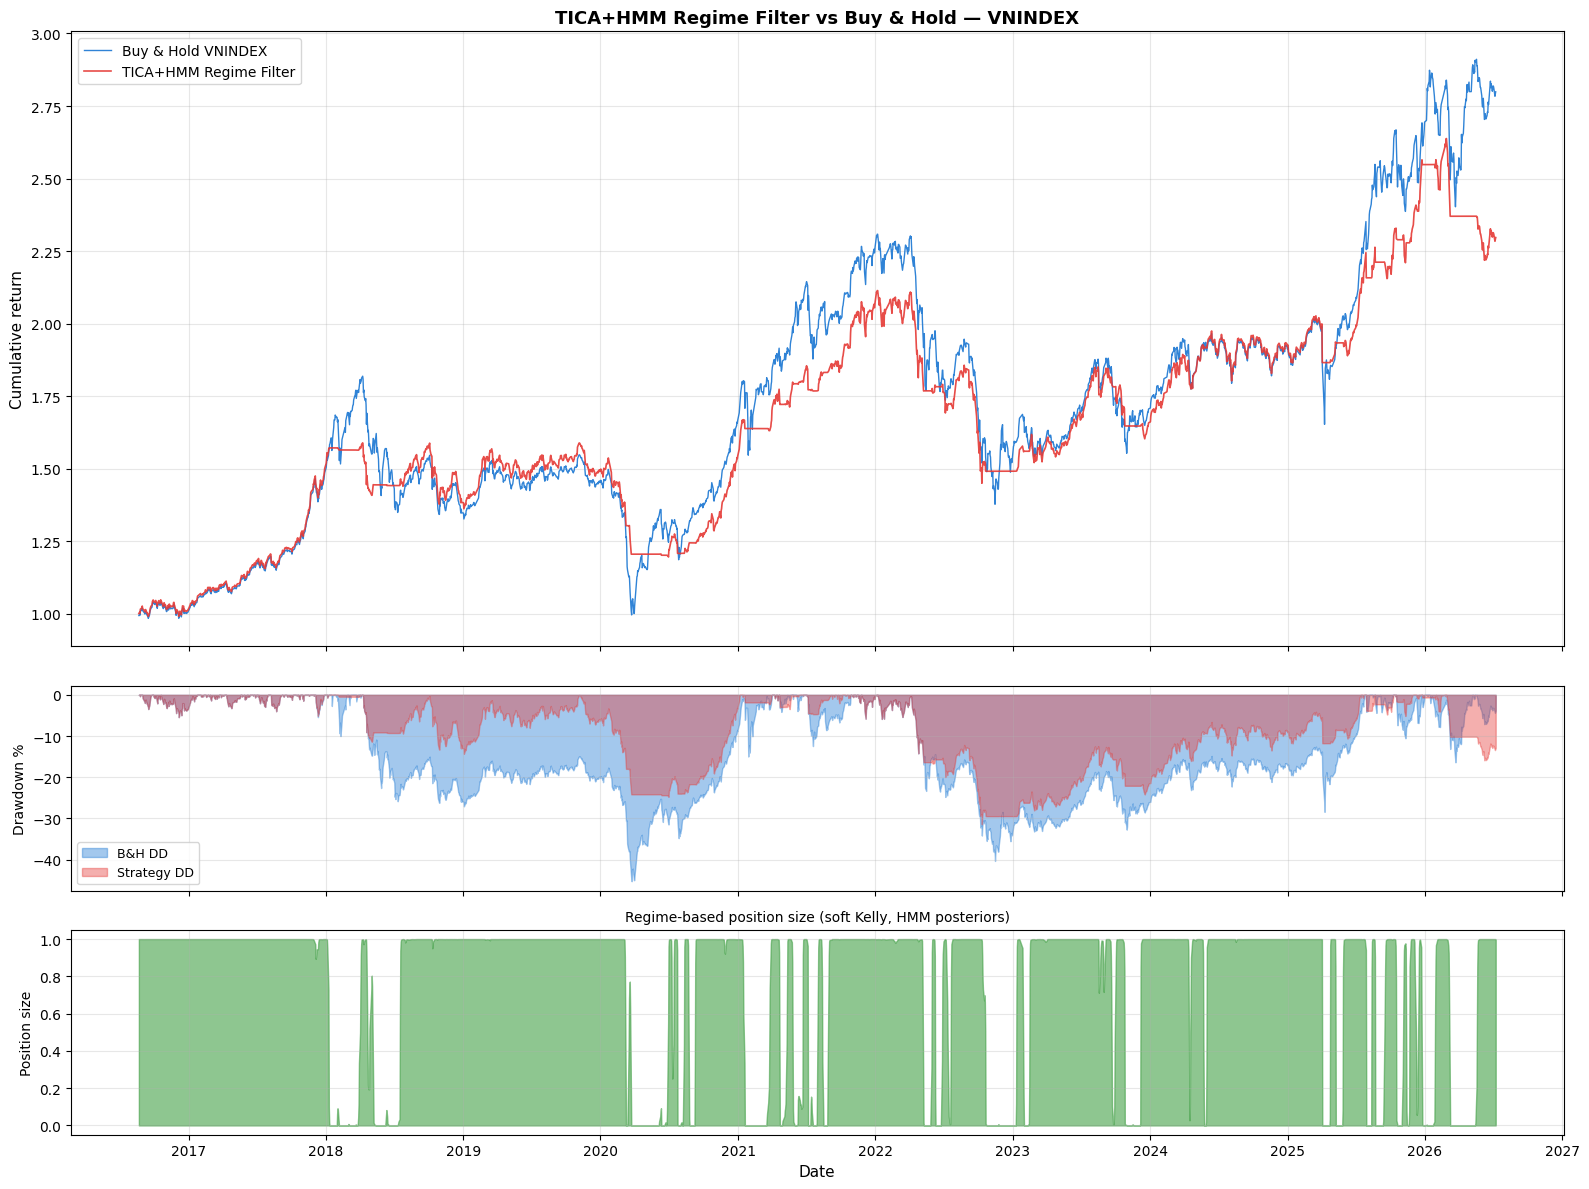


Current position size (today): 1.00


In [17]:
# =============================================================================
# §6 — RISK-AWARE TRADING OVERLAY (Kelly-inspired)
# =============================================================================

# ── Define per-regime risk multipliers ────────────────────────────────────────
LABEL_TO_SCALE = {
    'Risk-On'               : 1.0,
    'Risk-On (Elevated Vol)': 1.0,
    'Caution'               : 0.3,
    'Risk-Off'              : 0.0,
    'Crisis'                : 0.0,
    'Extreme Crisis'        : 0.0,
}

regime_scales = np.array([LABEL_TO_SCALE[regime_meta[r]] for r in range(best_k_tica)])
print("Regime scales:")
for r in range(best_k_tica):
    print(f"  Regime {r} ({regime_meta[r]}): scale={regime_scales[r]}")

# ── Soft position size (probability-weighted) ─────────────────────────────────
soft_size = (probs_tica * regime_scales).sum(axis=1)
soft_size_series = pd.Series(soft_size, index=ic_df.index)

# ── Backtest ──────────────────────────────────────────────────────────────────
aligned_ret   = vnindex_ret.loc[ic_df.index]
strategy_ret  = aligned_ret * soft_size_series.shift(1).fillna(0)
bnh_ret       = aligned_ret

cum_strategy  = (1 + strategy_ret).cumprod()
cum_bnh       = (1 + bnh_ret).cumprod()

# ── Metrics ───────────────────────────────────────────────────────────────────
def metrics(rets, label):
    ann_r  = rets.mean() * 252 * 100
    ann_v  = rets.std()  * np.sqrt(252) * 100
    sharpe = ann_r / ann_v if ann_v > 0 else 0
    cum    = (1 + rets).cumprod()
    maxdd  = (cum / cum.cummax() - 1).min() * 100
    calmar = ann_r / (-maxdd + 1e-8)
    print(f"{label:<40} Ann.Ret={ann_r:+.1f}%  Vol={ann_v:.1f}%  "
          f"Sharpe={sharpe:.2f}  MaxDD={maxdd:.1f}%  Calmar={calmar:.2f}")

print(f"\n{'='*80}")
print("BACKTEST RESULTS (full history, no transaction costs)")
print(f"{'='*80}")
metrics(bnh_ret,      "Buy & Hold VNINDEX")
metrics(strategy_ret, "TICA+HMM Regime Filter (soft Kelly)")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(16, 12), sharex=True,
                                      gridspec_kw={'height_ratios': [3, 1, 1]})

ax1.plot(cum_bnh,      color='#1976D2', linewidth=1.0, label='Buy & Hold VNINDEX', alpha=0.9)
ax1.plot(cum_strategy, color='#E53935', linewidth=1.2, label='TICA+HMM Regime Filter', alpha=0.9)
ax1.set_ylabel('Cumulative return', fontsize=11)
ax1.set_title('TICA+HMM Regime Filter vs Buy & Hold — VNINDEX', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

bnh_dd   = ((1 + bnh_ret).cumprod()      / (1 + bnh_ret).cumprod().cummax()      - 1) * 100
strat_dd = ((1 + strategy_ret).cumprod() / (1 + strategy_ret).cumprod().cummax() - 1) * 100
ax2.fill_between(bnh_dd.index,   bnh_dd.values,   color='#1976D2', alpha=0.4, label='B&H DD')
ax2.fill_between(strat_dd.index, strat_dd.values,  color='#E53935', alpha=0.4, label='Strategy DD')
ax2.set_ylabel('Drawdown %', fontsize=10)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

ax3.fill_between(soft_size_series.index, soft_size_series.values, color='#43A047', alpha=0.6)
ax3.set_ylabel('Position size', fontsize=10)
ax3.set_xlabel('Date', fontsize=11)
ax3.set_ylim(-0.05, 1.05)
ax3.set_title('Regime-based position size (soft Kelly, HMM posteriors)', fontsize=10)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('regime_tica_backtest.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nCurrent position size (today): {soft_size_series.iloc[-1]:.2f}")

## §7 — Hyperparameter Tuning: TICA Lag × Volatility Window
Grid search over `lagtime` and `vol_window` (controls the RV feature used as VIX proxy).  
Position = sigmoid(IC1) — same as article's approach, keeps it fast for grid scan.  
Metric = annualised Sharpe of the regime-filtered strategy (1-day lag on signal).

In [18]:
# =============================================================================
# §7 — HYPERPARAMETER TUNING: TICA lagtime × vol_window
# =============================================================================
from deeptime.decomposition import TICA
from sklearn.preprocessing import StandardScaler
import warnings

def sharpe(r):
    return np.sqrt(252) * r.mean() / r.std() if r.std() > 0 else np.nan

def calmar(r):
    ann_r = r.mean() * 252
    maxdd = ((1 + r).cumprod() / (1 + r).cumprod().cummax() - 1).min()
    return ann_r / (-maxdd + 1e-8) if maxdd < 0 else np.nan

# ── Parameter grid (extended to test lag=40) ─────────────────────────────
lag_list     = [5, 10, 20, 40]
vol_win_list = [10, 20, 30]

train_ratio = 0.8
base_ret    = vnindex_close.pct_change().dropna()
ann         = np.sqrt(252)

sharpe_tbl = pd.DataFrame(np.nan, index=vol_win_list, columns=lag_list, dtype=float)
calmar_tbl = pd.DataFrame(np.nan, index=vol_win_list, columns=lag_list, dtype=float)

# ── Grid search ───────────────────────────────────────────────────────────────
for vol_w in vol_win_list:
    rv_short = base_ret.rolling(max(vol_w // 2, 5)).std() * ann * 100
    rv_main  = base_ret.rolling(vol_w).std()              * ann * 100
    rv_long  = base_ret.rolling(vol_w * 3).std()          * ann * 100
    vts      = rv_short / (rv_long + 1e-8)
    vov_w    = rv_main.rolling(vol_w).std()
    skew_w   = base_ret.rolling(vol_w).apply(skew,     raw=True)
    kurt_w   = base_ret.rolling(vol_w).apply(kurtosis, raw=True)

    feat = pd.DataFrame({
        'ret1d'  : base_ret,
        'rv_main': rv_main,
        'vol_ts' : vts,
        'vov'    : vov_w,
        'mom5'   : vnindex_close.pct_change(5),
        'mom20'  : vnindex_close.pct_change(20),
        'skew'   : skew_w,
        'kurt'   : kurt_w,
    }).dropna()

    n_train    = int(len(feat) * train_ratio)
    train_feat = feat.iloc[:n_train]
    test_feat  = feat.iloc[n_train:]

    sc      = StandardScaler()
    X_train = sc.fit_transform(train_feat.values)
    X_test  = sc.transform(test_feat.values)

    for lag in lag_list:
        # Skip if lag >= train length (TICA requirement)
        if lag >= len(X_train):
            continue
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            try:
                tica_g = TICA(lagtime=lag, dim=1)
                tica_g.fit(X_train)
                model_g  = tica_g.fetch_model()
                ic1_test = model_g.transform(X_test)[:, 0]

                tmp = test_feat.copy()
                tmp['ic1']      = ic1_test
                tmp['position'] = 1.0 / (1.0 + np.exp(tmp['ic1']))
                tmp['strat_r']  = tmp['position'].shift(1) * tmp['ret1d']
                tmp = tmp.dropna()

                sharpe_tbl.loc[vol_w, lag] = sharpe(tmp['strat_r'])
                calmar_tbl.loc[vol_w, lag] = calmar(tmp['strat_r'])
            except Exception:
                pass

print("Sharpe Ratio grid (out-of-sample):")
print(sharpe_tbl.round(3).to_string())
print("\nCalmar Ratio grid (out-of-sample):")
print(calmar_tbl.round(3).to_string())

best_idx = sharpe_tbl.stack().idxmax()
print(f"\nBest by Sharpe → vol_window={best_idx[0]}, lag={best_idx[1]}, "
      f"Sharpe={sharpe_tbl.loc[best_idx]:.3f}")

Sharpe Ratio grid (out-of-sample):
       5      10     20     40
10  0.778  0.755  0.962  0.992
20  0.528  0.606  0.726  0.911
30  0.538  0.583  0.653  0.768

Calmar Ratio grid (out-of-sample):
       5      10     20     40
10  0.951  0.808  0.952  1.016
20  0.481  0.584  0.681  0.863
30  0.447  0.508  0.604  0.701

Best by Sharpe → vol_window=10, lag=40, Sharpe=0.992


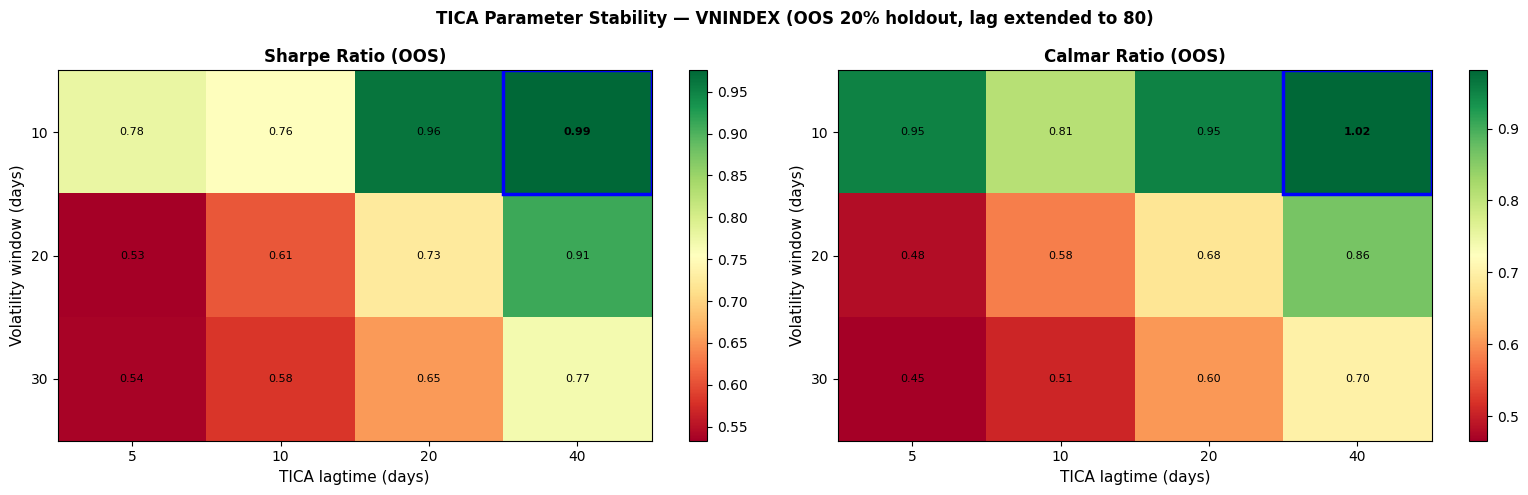

Best Sharpe: vol_w=10, lag=40, Sharpe=0.992
Tip: set FORCE_K=3 in §4 for cleaner 3-regime semantics (Bull / Bear / Crisis)


In [19]:
# =============================================================================
# §7b — HEATMAP VISUALISATION
# =============================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

for ax, tbl, title in [
    (ax1, sharpe_tbl, 'Sharpe Ratio (OOS)'),
    (ax2, calmar_tbl, 'Calmar Ratio (OOS)'),
]:
    vals = tbl.values.astype(float)
    im   = ax.imshow(vals, cmap='RdYlGn', aspect='auto',
                     vmin=np.nanpercentile(vals, 5),
                     vmax=np.nanpercentile(vals, 95))
    plt.colorbar(im, ax=ax)

    ax.set_xticks(range(len(lag_list)))
    ax.set_xticklabels(lag_list)
    ax.set_yticks(range(len(vol_win_list)))
    ax.set_yticklabels(vol_win_list)
    ax.set_xlabel('TICA lagtime (days)', fontsize=11)
    ax.set_ylabel('Volatility window (days)', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')

    for i in range(len(vol_win_list)):
        for j in range(len(lag_list)):
            v = vals[i, j]
            if not np.isnan(v):
                is_best = (vol_win_list[i], lag_list[j]) == best_idx
                ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                        fontsize=8, color='black', fontweight='bold' if is_best else 'normal')

    bi, bj = vol_win_list.index(best_idx[0]), lag_list.index(best_idx[1])
    from matplotlib.patches import Rectangle
    ax.add_patch(Rectangle((bj - 0.5, bi - 0.5), 1, 1,
                            fill=False, edgecolor='blue', lw=2.5))

plt.suptitle('TICA Parameter Stability — VNINDEX (OOS 20% holdout, lag extended to 80)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('regime_tica_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Best Sharpe: vol_w={best_idx[0]}, lag={best_idx[1]}, Sharpe={sharpe_tbl.loc[best_idx]:.3f}")
print("Tip: set FORCE_K=3 in §4 for cleaner 3-regime semantics (Bull / Bear / Crisis)")